In [100]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("📦 Libraries imported successfully!")
print("🎨 Plotting style configured")

📦 Libraries imported successfully!
🎨 Plotting style configured


# Multi-Dataset Results Analysis

This notebook analyzes and compares countersink depth measurements across multiple datasets:
- `october_15_dataset_y_step_12microns`
- `october_15_dataset_y_step_20microns` 
- `october_16_dataset_A`
- `october_16_dataset_B`

## Analysis Objectives:
1. **Load and combine** all results.json files
2. **Visualize** measurements for each hole across datasets
3. **Calculate variability** (range, std dev, variance) for each hole across different datasets
4. **Analyze consistency** of measurements for individual holes across scanning conditions

In [ ]:
# Define dataset paths
dataset_paths = {
    'oct15_12microns': 'october_15_dataset_y_step_12microns/analysis_results/results.json',
    'oct15_20microns': 'october_15_dataset_y_step_20microns/analysis_results/results.json',
    'oct16_dataset_A': 'october_16_dataset_A/analysis_results/results.json',
    'oct16_dataset_B': 'october_16_dataset_B/analysis_results/results.json'
}

def load_results_json(filepath: str) -> Dict:
    """Load and return results from JSON file"""
    try:
        with open(filepath, 'r') as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"⚠️  File not found: {filepath}")
        return {}
    except json.JSONDecodeError as e:
        print(f"❌ Error reading JSON {filepath}: {e}")
        return {}

# Load all datasets
all_results = {}
successful_loads = 0

print("📂 Loading results from all datasets...")
for dataset_name, filepath in dataset_paths.items():
    print(f"   Loading {dataset_name}...")
    results = load_results_json(filepath)
    if results:
        all_results[dataset_name] = results
        successful_loads += 1
        print(f"   ✅ {dataset_name}: {len(results)} holes loaded")
    else:
        print(f"   ❌ Failed to load {dataset_name}")

print(f"\n📊 Summary: {successful_loads}/{len(dataset_paths)} datasets loaded successfully")
print(f"Available datasets: {list(all_results.keys())}")

📂 Loading results from all datasets...
   Loading oct15_12microns...
   ✅ oct15_12microns: 29 holes loaded
   Loading oct15_20microns...
   ✅ oct15_20microns: 29 holes loaded
   Loading oct16_dataset_A...
   ✅ oct16_dataset_A: 29 holes loaded
   Loading oct16_dataset_B...
   ✅ oct16_dataset_B: 29 holes loaded

📊 Summary: 4/4 datasets loaded successfully
Available datasets: ['oct15_12microns', 'oct15_20microns', 'oct16_dataset_A', 'oct16_dataset_B']


In [102]:
# Convert to pandas DataFrame for easier analysis
def create_combined_dataframe(all_results: Dict) -> pd.DataFrame:
    """Convert nested results dictionary to a flat DataFrame"""
    rows = []
    
    for dataset_name, dataset_results in all_results.items():
        for hole_name, measurements in dataset_results.items():
            rows.append({
                'dataset': dataset_name,
                'hole': hole_name,
                'left_depth': measurements['left_total_depth'],
                'right_depth': measurements['right_total_depth']
            })
    
    return pd.DataFrame(rows)

# Create combined DataFrame
df = create_combined_dataframe(all_results)

# Filter out Hole_number_1167
df = df[df['hole'] != 'Hole_number_1167']
print("🚫 Filtered out Hole_number_1167 from analysis")

print("📋 Combined DataFrame created:")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
print(f"   Unique holes: {df['hole'].nunique()}")
print(f"   Datasets: {df['dataset'].unique()}")

# Display first few rows
print("\n🔍 Sample data:")
print(df.head(10))

🚫 Filtered out Hole_number_1167 from analysis
📋 Combined DataFrame created:
   Shape: (112, 4)
   Columns: ['dataset', 'hole', 'left_depth', 'right_depth']
   Unique holes: 28
   Datasets: ['oct15_12microns' 'oct15_20microns' 'oct16_dataset_A' 'oct16_dataset_B']

🔍 Sample data:
            dataset              hole  left_depth  right_depth
1   oct15_12microns  Hole_number_1168    1.097247     1.052673
2   oct15_12microns  Hole_number_1169    1.093242     1.035225
3   oct15_12microns  Hole_number_1170    1.032836     1.051325
4   oct15_12microns  Hole_number_1171    1.098234     1.051579
5   oct15_12microns  Hole_number_1172    1.054027     1.012264
6   oct15_12microns  Hole_number_1173    1.057004     1.022737
7   oct15_12microns  Hole_number_1174    1.074640     1.013123
8   oct15_12microns  Hole_number_1175    1.059374     1.036953
9   oct15_12microns  Hole_number_1176    1.056309     1.023523
10  oct15_12microns  Hole_number_1177    1.063803     1.036557


## 1. Data Overview and Quality Check

In [103]:
# Check data availability for each hole across datasets
hole_coverage = df.groupby('hole')['dataset'].count().sort_values(ascending=False)

print("🔍 Data Coverage Analysis:")
print(f"Total unique holes: {len(hole_coverage)}")
print(f"Holes with all {len(all_results)} datasets: {(hole_coverage == len(all_results)).sum()}")
print(f"Holes with 3+ datasets: {(hole_coverage >= 3).sum()}")
print(f"Holes with 2+ datasets: {(hole_coverage >= 2).sum()}")

print("\n📊 Holes by number of datasets:")
coverage_counts = hole_coverage.value_counts().sort_index()
for num_datasets, count in coverage_counts.items():
    print(f"   {num_datasets} datasets: {count} holes")

# Show holes with different coverage
print(f"\n🎯 Complete coverage holes (all {len(all_results)} datasets):")
complete_holes = hole_coverage[hole_coverage == len(all_results)].index.tolist()
print(f"   {complete_holes[:10]}..." if len(complete_holes) > 10 else f"   {complete_holes}")

if len(complete_holes) < len(hole_coverage):
    incomplete_holes = hole_coverage[hole_coverage < len(all_results)]
    print(f"\n⚠️  Incomplete coverage holes:")
    for hole, count in incomplete_holes.items():
        missing_datasets = set(all_results.keys()) - set(df[df['hole'] == hole]['dataset'].values)
        print(f"   {hole}: {count}/{len(all_results)} datasets (missing: {missing_datasets})")

🔍 Data Coverage Analysis:
Total unique holes: 28
Holes with all 4 datasets: 28
Holes with 3+ datasets: 28
Holes with 2+ datasets: 28

📊 Holes by number of datasets:
   4 datasets: 28 holes

🎯 Complete coverage holes (all 4 datasets):
   ['Hole_number_1168', 'Hole_number_1169', 'Hole_number_1194', 'Hole_number_1193', 'Hole_number_1192', 'Hole_number_1191', 'Hole_number_1190', 'Hole_number_1189', 'Hole_number_1188', 'Hole_number_1187']...

Total unique holes: 28
Holes with all 4 datasets: 28
Holes with 3+ datasets: 28
Holes with 2+ datasets: 28

📊 Holes by number of datasets:
   4 datasets: 28 holes

🎯 Complete coverage holes (all 4 datasets):
   ['Hole_number_1168', 'Hole_number_1169', 'Hole_number_1194', 'Hole_number_1193', 'Hole_number_1192', 'Hole_number_1191', 'Hole_number_1190', 'Hole_number_1189', 'Hole_number_1188', 'Hole_number_1187']...


## 2. Visualization: Measurements Across Datasets

🚫 Filtered out Hole_number_1167 from plotting (if present)
📊 Using 15 holes with complete data


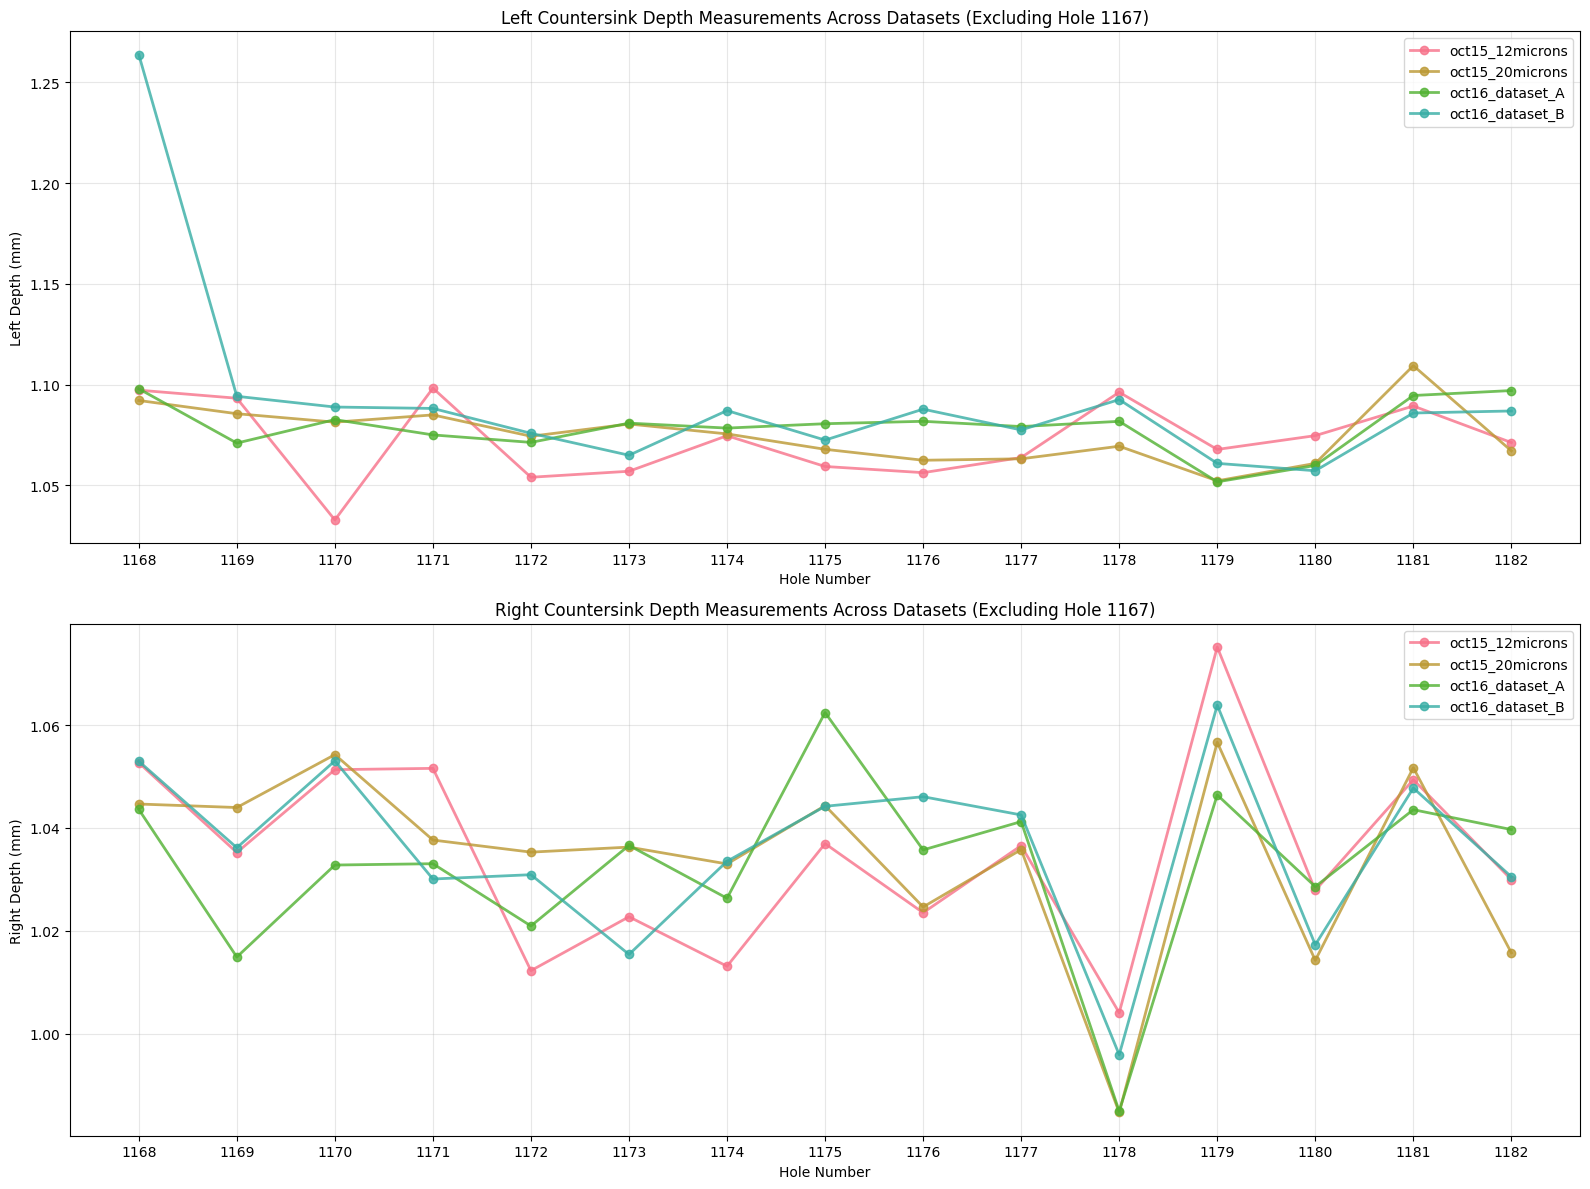

In [104]:
# Create comprehensive visualization
def plot_hole_measurements(df: pd.DataFrame, max_holes_per_plot: int = 15):
    """Plot measurements for each hole across datasets"""
    
    # Filter out Hole_number_1167 if it exists in the data
    df_filtered = df[df['hole'] != 'Hole_number_1167']
    print(f"🚫 Filtered out Hole_number_1167 from plotting (if present)")
    
    # Get holes with complete data for cleaner visualization
    complete_holes = df_filtered.groupby('hole')['dataset'].count()
    complete_holes = complete_holes[complete_holes == len(all_results)].index.tolist()
    
    if len(complete_holes) == 0:
        # If no complete holes, use holes with most data
        hole_counts = df_filtered.groupby('hole')['dataset'].count().sort_values(ascending=False)
        complete_holes = hole_counts.head(max_holes_per_plot).index.tolist()
        print(f"⚠️  No holes with complete data. Using {len(complete_holes)} holes with most coverage.")
    else:
        print(f"📊 Using {min(len(complete_holes), max_holes_per_plot)} holes with complete data")
    
    # Limit number of holes for readability
    plot_holes = complete_holes[:max_holes_per_plot]
    plot_df = df_filtered[df_filtered['hole'].isin(plot_holes)]
    
    # Create subplots for left and right depths
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))
    
    # Extract hole numbers for proper sorting
    plot_df['hole_num'] = plot_df['hole'].str.extract(r'(\d+)').astype(int)
    plot_df = plot_df.sort_values('hole_num')
    
    # Plot 1: Left depth measurements
    for dataset in all_results.keys():
        dataset_data = plot_df[plot_df['dataset'] == dataset]
        ax1.plot(dataset_data['hole_num'], dataset_data['left_depth'], 
                'o-', label=dataset, linewidth=2, markersize=6, alpha=0.8)
    
    ax1.set_xlabel('Hole Number')
    ax1.set_ylabel('Left Depth (mm)')
    ax1.set_title('Left Countersink Depth Measurements Across Datasets (Excluding Hole 1167)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(plot_df['hole_num'].unique())
    
    # Plot 2: Right depth measurements
    for dataset in all_results.keys():
        dataset_data = plot_df[plot_df['dataset'] == dataset]
        ax2.plot(dataset_data['hole_num'], dataset_data['right_depth'], 
                'o-', label=dataset, linewidth=2, markersize=6, alpha=0.8)
    
    ax2.set_xlabel('Hole Number')
    ax2.set_ylabel('Right Depth (mm)')
    ax2.set_title('Right Countersink Depth Measurements Across Datasets (Excluding Hole 1167)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(plot_df['hole_num'].unique())
    
    plt.tight_layout()
    plt.show()
    
    return plot_holes

# Create the plots
plotted_holes = plot_hole_measurements(df)

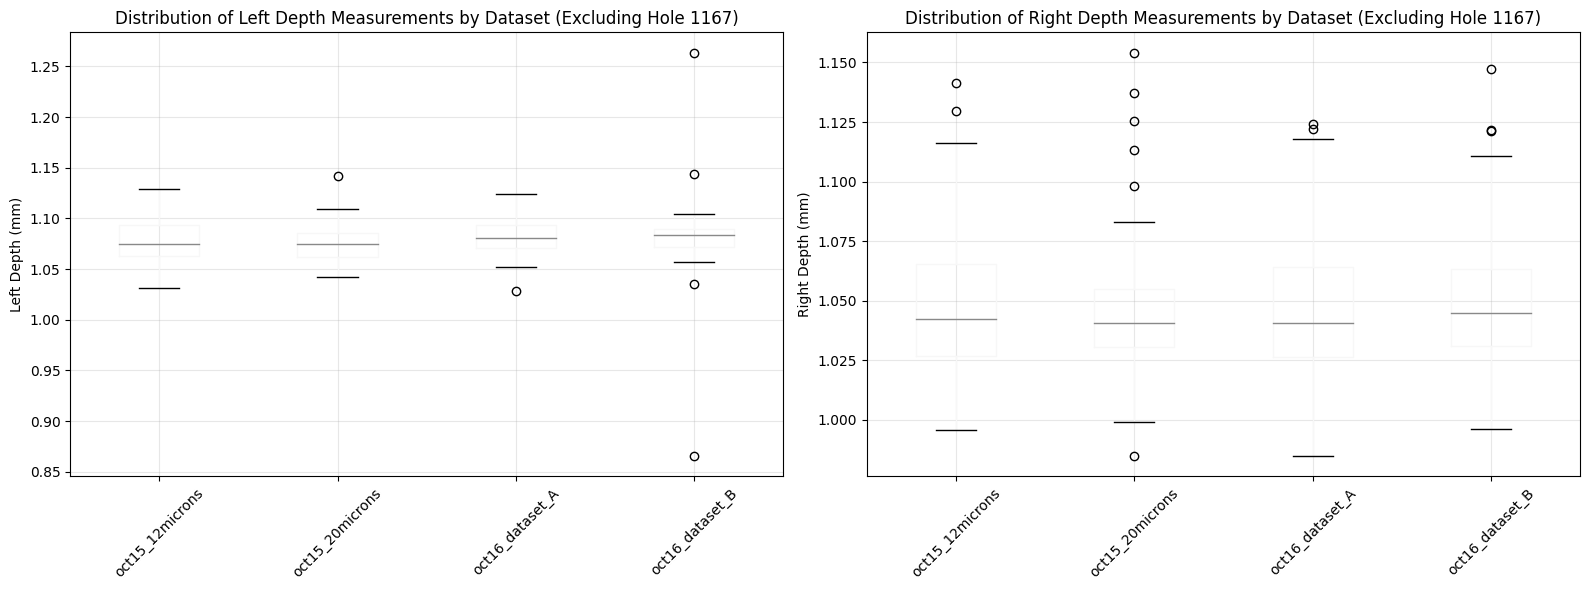

📊 Summary Statistics by Dataset (Excluding Hole 1167):

🔵 Left Depth Statistics:
                 count    mean     std     min     max
dataset                                               
oct15_12microns     28  1.0781  0.0232  1.0310  1.1288
oct15_20microns     28  1.0766  0.0214  1.0421  1.1417
oct16_dataset_A     28  1.0812  0.0201  1.0284  1.1244
oct16_dataset_B     28  1.0809  0.0577  0.8654  1.2638

🔴 Right Depth Statistics:
                 count    mean     std     min     max
dataset                                               
oct15_12microns     28  1.0503  0.0377  0.9957  1.1414
oct15_20microns     28  1.0508  0.0412  0.9847  1.1542
oct16_dataset_A     28  1.0497  0.0355  0.9849  1.1243
oct16_dataset_B     28  1.0510  0.0367  0.9959  1.1474


In [105]:
# Create box plots to show distribution and variability
# Filter out Hole_number_1167 for box plots as well
df_box = df[df['hole'] != 'Hole_number_1167']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Box plot for left depths
df_pivot_left = df_box.pivot(index='hole', columns='dataset', values='left_depth')
df_pivot_left.boxplot(ax=ax1, rot=45)
ax1.set_title('Distribution of Left Depth Measurements by Dataset (Excluding Hole 1167)')
ax1.set_ylabel('Left Depth (mm)')
ax1.grid(True, alpha=0.3)

# Box plot for right depths  
df_pivot_right = df_box.pivot(index='hole', columns='dataset', values='right_depth')
df_pivot_right.boxplot(ax=ax2, rot=45)
ax2.set_title('Distribution of Right Depth Measurements by Dataset (Excluding Hole 1167)')
ax2.set_ylabel('Right Depth (mm)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics by dataset (excluding Hole_number_1167)
print("📊 Summary Statistics by Dataset (Excluding Hole 1167):")
print("\n🔵 Left Depth Statistics:")
left_stats = df_box.groupby('dataset')['left_depth'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
print(left_stats)

print("\n🔴 Right Depth Statistics:")
right_stats = df_box.groupby('dataset')['right_depth'].agg(['count', 'mean', 'std', 'min', 'max']).round(4)
print(right_stats)

## 3. Statistical Analysis: Range, Standard Deviation, and Variance

In [106]:
def calculate_hole_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate range, std dev, and variance for each hole across different datasets"""
    
    # Filter out Hole_number_1167 from statistics calculation
    df_stats = df[df['hole'] != 'Hole_number_1167']
    
    hole_stats = []
    
    for hole in df_stats['hole'].unique():
        hole_data = df_stats[df_stats['hole'] == hole]
        
        # Only calculate if we have multiple measurements (from different datasets)
        if len(hole_data) >= 2:
            left_values = hole_data['left_depth'].values
            right_values = hole_data['right_depth'].values
            
            stats = {
                'hole': hole,
                'num_datasets': len(hole_data),
                'datasets': ', '.join(sorted(hole_data['dataset'].unique())),
                
                # Left depth statistics across datasets
                'left_min': np.min(left_values),
                'left_max': np.max(left_values),
                'left_range': np.max(left_values) - np.min(left_values),
                'left_mean': np.mean(left_values),
                'left_std': np.std(left_values, ddof=1) if len(left_values) > 1 else 0,
                'left_variance': np.var(left_values, ddof=1) if len(left_values) > 1 else 0,
                
                # Right depth statistics across datasets
                'right_min': np.min(right_values),
                'right_max': np.max(right_values),
                'right_range': np.max(right_values) - np.min(right_values),
                'right_mean': np.mean(right_values),
                'right_std': np.std(right_values, ddof=1) if len(right_values) > 1 else 0,
                'right_variance': np.var(right_values, ddof=1) if len(right_values) > 1 else 0,
            }
            
            hole_stats.append(stats)
    
    return pd.DataFrame(hole_stats)

# Calculate statistics for each hole across datasets
hole_statistics = calculate_hole_statistics(df)

print("📈 Per-Hole Statistics Across Datasets (Excluding Hole 1167):")
print(f"   Analyzed {len(hole_statistics)} holes with measurements from multiple datasets")
print(f"   Each hole's variability represents differences across scanning conditions")
print(f"   Columns: {list(hole_statistics.columns)}")

# Display sample of hole statistics
print("\n🔍 Sample Hole Statistics (Variability Across Datasets):")
display_cols = ['hole', 'num_datasets', 'left_range', 'left_std', 'right_range', 'right_std']
print(hole_statistics[display_cols].head(10).round(4))

📈 Per-Hole Statistics Across Datasets (Excluding Hole 1167):
   Analyzed 28 holes with measurements from multiple datasets
   Each hole's variability represents differences across scanning conditions
   Columns: ['hole', 'num_datasets', 'datasets', 'left_min', 'left_max', 'left_range', 'left_mean', 'left_std', 'left_variance', 'right_min', 'right_max', 'right_range', 'right_mean', 'right_std', 'right_variance']

🔍 Sample Hole Statistics (Variability Across Datasets):
               hole  num_datasets  left_range  left_std  right_range  \
0  Hole_number_1168             4      0.1716    0.0840       0.0094   
1  Hole_number_1169             4      0.0232    0.0107       0.0291   
2  Hole_number_1170             4      0.0560    0.0259       0.0215   
3  Hole_number_1171             4      0.0232    0.0096       0.0215   
4  Hole_number_1172             4      0.0218    0.0101       0.0230   
5  Hole_number_1173             4      0.0239    0.0118       0.0212   
6  Hole_number_1174     

In [107]:
# Calculate overall averages and summary statistics
def calculate_overall_statistics(hole_stats: pd.DataFrame) -> Dict:
    """Calculate average variability across all holes (how much each hole varies across datasets)"""
    
    # Filter out holes with only one measurement (no variability across datasets)
    multi_measurement_holes = hole_stats[hole_stats['num_datasets'] >= 2]
    
    overall_stats = {
        'total_holes_analyzed': len(multi_measurement_holes),
        'total_holes_in_data': len(hole_stats),
        
        # Average variability for left depths (across datasets for each hole)
        'avg_left_range': multi_measurement_holes['left_range'].mean(),
        'avg_left_std': multi_measurement_holes['left_std'].mean(),
        'avg_left_variance': multi_measurement_holes['left_variance'].mean(),
        
        # Average variability for right depths (across datasets for each hole)
        'avg_right_range': multi_measurement_holes['right_range'].mean(),
        'avg_right_std': multi_measurement_holes['right_std'].mean(),
        'avg_right_variance': multi_measurement_holes['right_variance'].mean(),
        
        # Range of variability (meta-statistics)
        'left_range_min': multi_measurement_holes['left_range'].min(),
        'left_range_max': multi_measurement_holes['left_range'].max(),
        'right_range_min': multi_measurement_holes['right_range'].min(),
        'right_range_max': multi_measurement_holes['right_range'].max(),
        
        # Standard deviation of variability measures
        'left_std_std': multi_measurement_holes['left_std'].std(),
        'right_std_std': multi_measurement_holes['right_std'].std(),
    }
    
    return overall_stats

# Calculate overall statistics
overall_stats = calculate_overall_statistics(hole_statistics)

print("🎯 OVERALL VARIABILITY SUMMARY (Excluding Hole 1167)")
print("=" * 60)
print("📊 Analysis: How much each hole varies across different datasets")
print(f"📊 Holes analyzed: {overall_stats['total_holes_analyzed']} (with ≥2 dataset measurements)")
print(f"📊 Total holes in data: {overall_stats['total_holes_in_data']}")

print(f"\n🔵 LEFT DEPTH VARIABILITY ACROSS DATASETS:")
print(f"   Average Range per Hole: {overall_stats['avg_left_range']:.4f} mm")
print(f"   Average Std Dev per Hole: {overall_stats['avg_left_std']:.4f} mm")
print(f"   Average Variance per Hole: {overall_stats['avg_left_variance']:.6f} mm²")
print(f"   Range of Hole Ranges: {overall_stats['left_range_min']:.4f} - {overall_stats['left_range_max']:.4f} mm")
print(f"   Std Dev of Hole Std Devs: {overall_stats['left_std_std']:.4f} mm")

print(f"\n🔴 RIGHT DEPTH VARIABILITY ACROSS DATASETS:")
print(f"   Average Range per Hole: {overall_stats['avg_right_range']:.4f} mm")
print(f"   Average Std Dev per Hole: {overall_stats['avg_right_std']:.4f} mm")
print(f"   Average Variance per Hole: {overall_stats['avg_right_variance']:.6f} mm²")
print(f"   Range of Hole Ranges: {overall_stats['right_range_min']:.4f} - {overall_stats['right_range_max']:.4f} mm")
print(f"   Std Dev of Hole Std Devs: {overall_stats['right_std_std']:.4f} mm")

print(f"\n💡 Interpretation:")
print(f"   - These statistics show how consistently each hole is measured across datasets")
print(f"   - Lower values indicate more consistent measurements across scanning conditions")
print(f"   - Higher values suggest greater sensitivity to scanning parameters")

🎯 OVERALL VARIABILITY SUMMARY (Excluding Hole 1167)
📊 Analysis: How much each hole varies across different datasets
📊 Holes analyzed: 28 (with ≥2 dataset measurements)
📊 Total holes in data: 28

🔵 LEFT DEPTH VARIABILITY ACROSS DATASETS:
   Average Range per Hole: 0.0397 mm
   Average Std Dev per Hole: 0.0184 mm
   Average Variance per Hole: 0.000786 mm²
   Range of Hole Ranges: 0.0125 - 0.2083 mm
   Std Dev of Hole Std Devs: 0.0216 mm

🔴 RIGHT DEPTH VARIABILITY ACROSS DATASETS:
   Average Range per Hole: 0.0231 mm
   Average Std Dev per Hole: 0.0104 mm
   Average Variance per Hole: 0.000120 mm²
   Range of Hole Ranges: 0.0067 - 0.0403 mm
   Std Dev of Hole Std Devs: 0.0036 mm

💡 Interpretation:
   - These statistics show how consistently each hole is measured across datasets
   - Lower values indicate more consistent measurements across scanning conditions
   - Higher values suggest greater sensitivity to scanning parameters


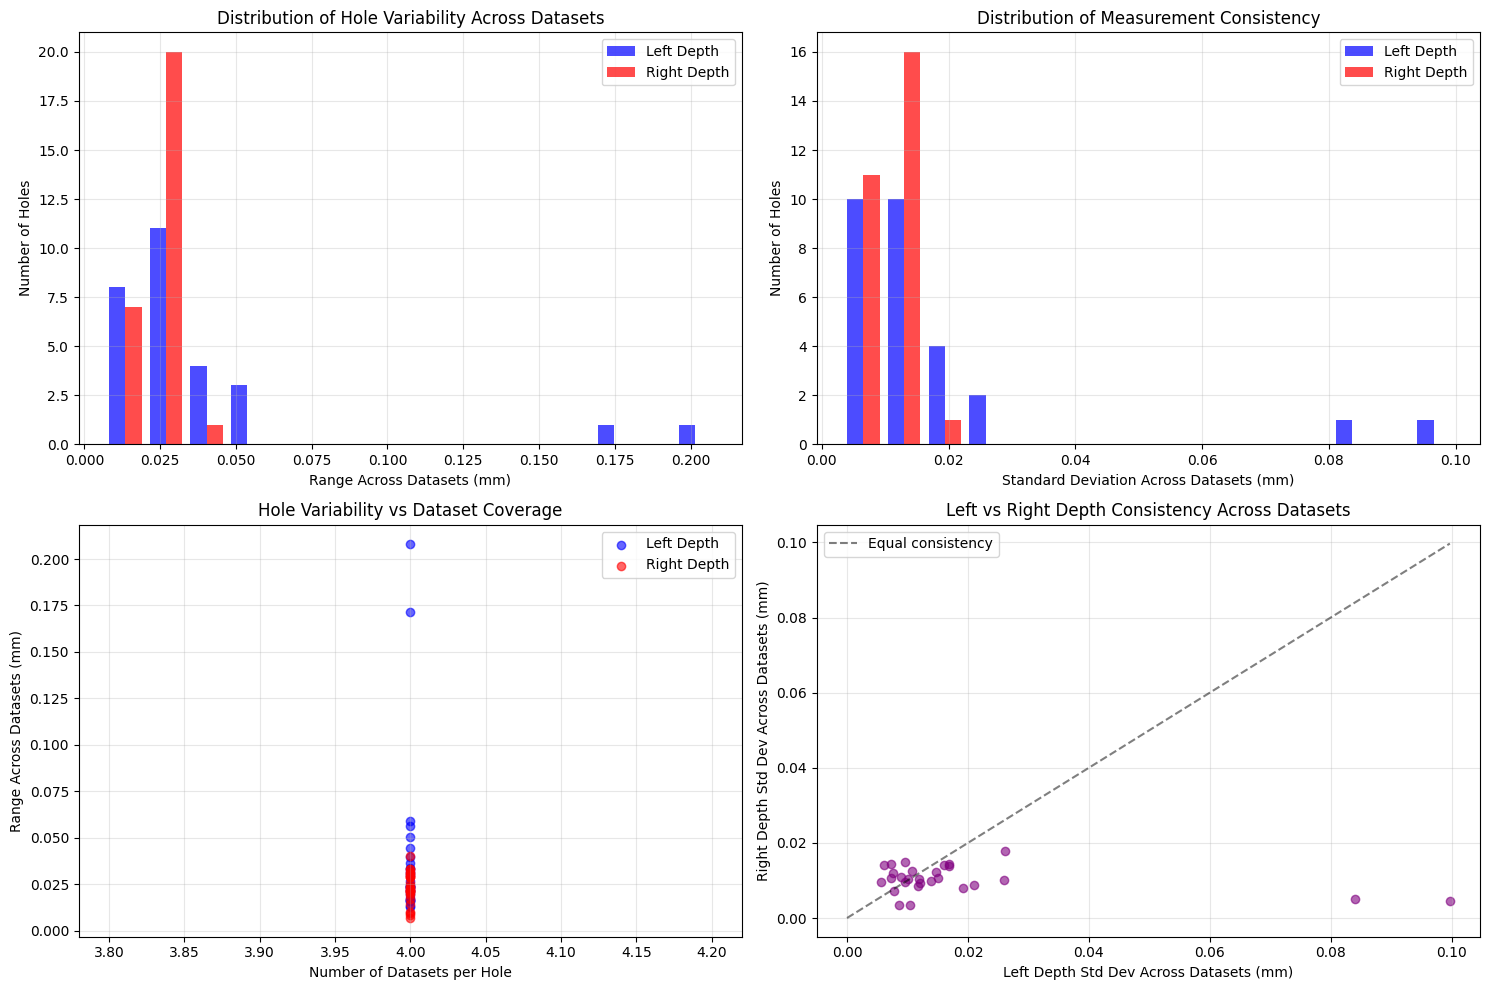

In [108]:
# Visualize the variability distributions across datasets
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Filter for holes with multiple measurements
multi_measurement_stats = hole_statistics[hole_statistics['num_datasets'] >= 2]

# Plot 1: Range distributions (how much each hole varies across datasets)
ax1.hist([multi_measurement_stats['left_range'], multi_measurement_stats['right_range']], 
         bins=15, alpha=0.7, label=['Left Depth', 'Right Depth'], color=['blue', 'red'])
ax1.set_xlabel('Range Across Datasets (mm)')
ax1.set_ylabel('Number of Holes')
ax1.set_title('Distribution of Hole Variability Across Datasets')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Standard deviation distributions (consistency across datasets)
ax2.hist([multi_measurement_stats['left_std'], multi_measurement_stats['right_std']], 
         bins=15, alpha=0.7, label=['Left Depth', 'Right Depth'], color=['blue', 'red'])
ax2.set_xlabel('Standard Deviation Across Datasets (mm)')
ax2.set_ylabel('Number of Holes')
ax2.set_title('Distribution of Measurement Consistency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Variability vs Number of Datasets
ax3.scatter(multi_measurement_stats['num_datasets'], multi_measurement_stats['left_range'], 
           alpha=0.6, label='Left Depth', color='blue')
ax3.scatter(multi_measurement_stats['num_datasets'], multi_measurement_stats['right_range'], 
           alpha=0.6, label='Right Depth', color='red')
ax3.set_xlabel('Number of Datasets per Hole')
ax3.set_ylabel('Range Across Datasets (mm)')
ax3.set_title('Hole Variability vs Dataset Coverage')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Left vs Right consistency comparison
ax4.scatter(multi_measurement_stats['left_std'], multi_measurement_stats['right_std'], 
           alpha=0.6, color='purple')
ax4.set_xlabel('Left Depth Std Dev Across Datasets (mm)')
ax4.set_ylabel('Right Depth Std Dev Across Datasets (mm)')
ax4.set_title('Left vs Right Depth Consistency Across Datasets')
ax4.grid(True, alpha=0.3)

# Add diagonal line for reference
max_std = max(multi_measurement_stats['left_std'].max(), multi_measurement_stats['right_std'].max())
ax4.plot([0, max_std], [0, max_std], 'k--', alpha=0.5, label='Equal consistency')
ax4.legend()

plt.tight_layout()
plt.show()

## 4. Detailed Analysis Tables

In [109]:
# Show holes with highest and lowest consistency across datasets
print("🔍 DETAILED CONSISTENCY ANALYSIS ACROSS DATASETS")
print("=" * 60)

# Holes with highest variability (least consistent across datasets)
print("\n📈 TOP 10 HOLES WITH HIGHEST VARIABILITY (Least Consistent Across Datasets):")
print("\n🔵 Left Depth - Highest Variability Across Datasets:")
highest_left_range = multi_measurement_stats.nlargest(10, 'left_range')[['hole', 'num_datasets', 'datasets', 'left_range', 'left_std']]
print(highest_left_range.round(4))

print("\n🔴 Right Depth - Highest Variability Across Datasets:")
highest_right_range = multi_measurement_stats.nlargest(10, 'right_range')[['hole', 'num_datasets', 'datasets', 'right_range', 'right_std']]
print(highest_right_range.round(4))

# Holes with lowest variability (most consistent across datasets)
print("\n📉 TOP 10 HOLES WITH LOWEST VARIABILITY (Most Consistent Across Datasets):")
print("\n🔵 Left Depth - Most Consistent Across Datasets:")
lowest_left_range = multi_measurement_stats.nsmallest(10, 'left_range')[['hole', 'num_datasets', 'datasets', 'left_range', 'left_std']]
print(lowest_left_range.round(4))

print("\n🔴 Right Depth - Most Consistent Across Datasets:")
lowest_right_range = multi_measurement_stats.nsmallest(10, 'right_range')[['hole', 'num_datasets', 'datasets', 'right_range', 'right_std']]
print(lowest_right_range.round(4))

print("\n💡 Interpretation:")
print("   - High variability holes may be more sensitive to scanning parameters")
print("   - Low variability holes show consistent measurements across different conditions")
print("   - This helps identify which holes are most reliably measured")

🔍 DETAILED CONSISTENCY ANALYSIS ACROSS DATASETS

📈 TOP 10 HOLES WITH HIGHEST VARIABILITY (Least Consistent Across Datasets):

🔵 Left Depth - Highest Variability Across Datasets:
                hole  num_datasets  \
17  Hole_number_1185             4   
0   Hole_number_1168             4   
21  Hole_number_1189             4   
2   Hole_number_1170             4   
27  Hole_number_1195             4   
24  Hole_number_1192             4   
22  Hole_number_1190             4   
19  Hole_number_1187             4   
20  Hole_number_1188             4   
26  Hole_number_1194             4   

                                             datasets  left_range  left_std  
17  oct15_12microns, oct15_20microns, oct16_datase...      0.2083    0.0997  
0   oct15_12microns, oct15_20microns, oct16_datase...      0.1716    0.0840  
21  oct15_12microns, oct15_20microns, oct16_datase...      0.0591    0.0261  
2   oct15_12microns, oct15_20microns, oct16_datase...      0.0560    0.0259  
27  oct15_12m

In [110]:
# Create summary table for export
summary_table = pd.DataFrame({
    'Metric': [
        'Total Holes Analyzed',
        'Average Left Range Across Datasets (mm)',
        'Average Right Range Across Datasets (mm)', 
        'Average Left Std Dev Across Datasets (mm)',
        'Average Right Std Dev Across Datasets (mm)',
        'Average Left Variance Across Datasets (mm²)',
        'Average Right Variance Across Datasets (mm²)',
        'Max Left Range Across Datasets (mm)',
        'Max Right Range Across Datasets (mm)',
        'Min Left Range Across Datasets (mm)',
        'Min Right Range Across Datasets (mm)'
    ],
    'Value': [
        overall_stats['total_holes_analyzed'],
        round(overall_stats['avg_left_range'], 4),
        round(overall_stats['avg_right_range'], 4),
        round(overall_stats['avg_left_std'], 4),
        round(overall_stats['avg_right_std'], 4),
        round(overall_stats['avg_left_variance'], 6),
        round(overall_stats['avg_right_variance'], 6),
        round(overall_stats['left_range_max'], 4),
        round(overall_stats['right_range_max'], 4),
        round(overall_stats['left_range_min'], 4),
        round(overall_stats['right_range_min'], 4)
    ]
})

print("📋 SUMMARY TABLE FOR EXPORT (Per-Hole Variability Across Datasets):")
print(summary_table.to_string(index=False))

# Save detailed results to CSV
hole_statistics.round(6).to_csv('hole_consistency_across_datasets_no_hole1167.csv', index=False)
summary_table.to_csv('measurement_consistency_summary_no_hole1167.csv', index=False)

print(f"\n💾 Files saved:")
print(f"   📄 hole_consistency_across_datasets_no_hole1167.csv - Variability of each hole across datasets")
print(f"   📄 measurement_consistency_summary_no_hole1167.csv - Overall consistency statistics")
print(f"\n📊 Analysis Focus:")
print(f"   - Each row represents one hole's variability across different scanning conditions")
print(f"   - Range/Std Dev values show how much that specific hole varies between datasets")
print(f"   - Lower values = more consistent measurements across scanning parameters")

📋 SUMMARY TABLE FOR EXPORT (Per-Hole Variability Across Datasets):
                                      Metric     Value
                        Total Holes Analyzed 28.000000
     Average Left Range Across Datasets (mm)  0.039700
    Average Right Range Across Datasets (mm)  0.023100
   Average Left Std Dev Across Datasets (mm)  0.018400
  Average Right Std Dev Across Datasets (mm)  0.010400
 Average Left Variance Across Datasets (mm²)  0.000786
Average Right Variance Across Datasets (mm²)  0.000120
         Max Left Range Across Datasets (mm)  0.208300
        Max Right Range Across Datasets (mm)  0.040300
         Min Left Range Across Datasets (mm)  0.012500
        Min Right Range Across Datasets (mm)  0.006700

💾 Files saved:
   📄 hole_consistency_across_datasets_no_hole1167.csv - Variability of each hole across datasets
   📄 measurement_consistency_summary_no_hole1167.csv - Overall consistency statistics

📊 Analysis Focus:
   - Each row represents one hole's variability across 

## 5. Key Findings and Conclusions

### Summary of Analysis:

1. **Data Coverage**: Analysis of measurement availability across multiple datasets
2. **Per-Hole Consistency**: Range, standard deviation, and variance for each individual hole across different datasets
3. **Overall Consistency Metrics**: Average variability statistics showing how holes vary across scanning conditions
4. **Visual Analysis**: Comprehensive plots showing measurement consistency patterns

### Key Metrics Calculated:
- **Range Across Datasets**: Difference between max and min measurements for each hole across all datasets
- **Standard Deviation Across Datasets**: Measure of consistency for each hole across scanning conditions
- **Variance Across Datasets**: Square of standard deviation, showing measurement reproducibility
- **Cross-Dataset Comparison**: How individual holes vary between different scanning parameters

### Analysis Focus:
This analysis answers: **"How consistently is each hole measured across different scanning conditions?"**
- Lower variability values indicate holes that are measured consistently regardless of scanning parameters
- Higher variability values indicate holes that are more sensitive to scanning conditions
- This helps identify which holes provide the most reliable measurements

### Exported Files:
- `hole_consistency_across_datasets_no_hole1167.csv`: Per-hole variability across all datasets
- `measurement_consistency_summary_no_hole1167.csv`: Overall consistency statistics